# Module 00 · Python for the R-native statistician

**Learning objectives.** By the end of this module you should be able to:

1. Predict when a NumPy indexing operation returns a view rather than a copy, and explain the consequences of mutating each;
2. Apply the formal broadcasting rules to predict result shapes, and avoid the silent shape bugs that R recycling habits produce;
3. Use pandas idiomatically where its semantics genuinely differ from the tidyverse: index alignment, copy-on-write, groupby machinery, and method chaining;
4. Structure all randomness through `np.random.default_rng`, including independent streams for parallel or modular simulations;
5. Build figures through the matplotlib object model and maintain a reproducible, `uv`-managed environment.

**Prerequisites.** No prior modules. Assumed background: working R with tidyverse fluency, and graduate-level statistics. This is the only module in the course where R comparisons appear; from module 01 onwards the course is Python-native.

**Estimated working time.** 3–4 hours including exercises.

The module seed constant is set in the first code cell. Every stochastic result in this notebook flows from it.

In [1]:
import sys
import warnings
from pathlib import Path
from time import perf_counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MODULE_SEED = 0
rng = np.random.default_rng(MODULE_SEED)

# Make the repository root importable so shared helpers resolve
# regardless of where the kernel was started.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.tunnel_mpl import apply_theme

apply_theme()

## 1 · Environment discipline

R users typically live inside a single system-wide library, perhaps disciplined by `renv` on serious projects. Python's packaging history is messier, and the ecosystem's answer is stricter: every project gets its own virtual environment, declared in a `pyproject.toml` and pinned by a lockfile. This repository uses [`uv`](https://docs.astral.sh/uv/), which plays the role of `renv` and the package installer simultaneously. Three commands cover almost everything: `uv sync` materialises the environment described by `pyproject.toml` and `uv.lock` into `.venv/`; `uv run <cmd>` executes a command inside that environment; `uv add <pkg>` adds a dependency and updates the lockfile in one step. The lockfile is committed, so two machines running `uv sync` obtain byte-identical dependency trees — the same guarantee `renv.lock` gives, enforced by default rather than by opt-in.

The one Python-specific trap for a notebook user is the *kernel*: the process that actually executes your cells, which need not be the environment you think you activated. A notebook attached to the wrong kernel imports the wrong package versions and produces unreproducible results without any error message. The check is one cell, and it is worth running at the top of any session that behaves strangely:

In [2]:
print(sys.executable)
print(sys.version)

/home/user/the-machine-learns/.venv/bin/python3
3.11.15 (main, Mar  3 2026, 09:26:23) [GCC 13.3.0]


The path should point inside this project's `.venv/`. If it points at a system Python, the kernel is wrong — restart the notebook via `uv run jupyter lab`, which launches Jupyter from inside the project environment.

## 2 · The NumPy array model

### 2.1 Arrays are typed buffers, not R vectors

An R atomic vector is a value with copy-on-modify semantics: `y <- x; y[1] <- 0` never changes `x`, because R (conceptually) copies on the write. A NumPy `ndarray` is a different object entirely: a fixed-width **buffer** of memory plus metadata — a `dtype` describing how to interpret each element, a `shape`, and `strides` giving the number of bytes to step per dimension. Indexing is 0-based and half-open, so `x[2:5]` selects positions 2, 3, 4 — three elements, not four.

In [3]:
x = np.arange(12).reshape(3, 4)
x

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [4]:
x.dtype, x.shape, x.strides

(dtype('int64'), (3, 4), (32, 8))

The strides say: to move one row, step 32 bytes (4 elements × 8 bytes); to move one column, step 8. This is why `x.T` costs nothing — NumPy swaps the strides and reuses the same buffer rather than moving any data. Operations that can be expressed as new metadata over the old buffer return **views**; operations that cannot, return copies.

The `dtype` is fixed-width and has no notion of R's `NA`. There is no missing integer in NumPy: `np.nan` is a float, so introducing missingness into integer data forces an upcast. pandas papers over this with either the float upcast or its nullable extension dtypes; the important thing at this stage is to notice when your integers have silently become floats.

In [5]:
pd.Series([1, None, 3]).dtype, pd.array([1, None, 3], dtype="Int64").dtype

(dtype('float64'), Int64Dtype())

The first is the silent float upcast (`NaN` is the missing marker); the second is pandas' nullable integer dtype, which keeps integers and represents missingness as `pd.NA`. This course mostly works with floats, where `NaN` behaves as R's `NA_real_` does, but the distinction matters whenever identifiers or counts pass through a pipeline with missing values.

### 2.2 Views versus copies

The single most consequential difference from R: **basic slicing returns a view, and mutating a view mutates the original.** R's copy-on-modify makes aliasing invisible; NumPy makes it your responsibility.

In [6]:
x = np.arange(10)
v = x[2:5]        # basic slice: a view
v[:] = -1
x

array([ 0,  1, -1, -1, -1,  5,  6,  7,  8,  9])

The write through `v` changed `x` — behaviour no R vector ever exhibits. By contrast, **advanced indexing** (an integer array or a boolean mask) cannot be expressed as strides over the old buffer, so it copies:

In [7]:
x = np.arange(10)
f = x[[2, 3, 4]]  # integer-array index: a copy
f[:] = 99
b = x[x > 6]      # boolean mask: a copy
b[:] = 99
x

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [8]:
np.shares_memory(x, x[2:5]), np.shares_memory(x, x[[2, 3, 4]])

(True, False)

`np.shares_memory` is the diagnostic when you are unsure. The rule to internalise: slices (`start:stop:step`), `reshape` on contiguous data, and transposes give views; integer-array and boolean indexing give copies. A view is a feature — it is why NumPy can manipulate large arrays without copying — but only once you stop expecting R's isolation guarantee.

### 2.3 Ufuncs and vectorisation

Like R, NumPy is fast only when loops happen in compiled code. A *ufunc* (universal function: `np.exp`, `np.add`, comparison operators, and so on) applies elementwise over whole arrays in C. The discipline is identical to R's — write array expressions, not element loops — but worth quantifying once, because the penalty for a Python-level loop is larger than the corresponding penalty in R:

In [9]:
def best_of(fn, repeats=5):
    """Minimum wall time over several runs, in milliseconds."""
    times = []
    for _ in range(repeats):
        t0 = perf_counter()
        fn()
        times.append(perf_counter() - t0)
    return 1e3 * min(times)


z = rng.normal(size=1_000_000)
t_loop = best_of(lambda: sum(zi * zi for zi in z))
t_ufunc = best_of(lambda: np.dot(z, z))
print(f"python loop: {t_loop:8.2f} ms")
print(f"vectorised : {t_ufunc:8.2f} ms   (×{t_loop / t_ufunc:.0f} speed-up)")

python loop:    96.26 ms
vectorised :     0.06 ms   (×1666 speed-up)


Two to three orders of magnitude is typical (the vectorised path here also benefits from `np.dot` dispatching to an optimised BLAS routine). When a computation resists array expression, the answer is usually a smarter formulation, not a loop; genuinely irreducible loops belong in the rare cases where performance does not matter or in compiled extensions, neither of which this course needs.

### 2.4 Broadcasting: the formal rules

R recycles: adding a length-3 vector to a length-6 vector silently repeats the shorter one, and a non-multiple length earns only a warning. NumPy replaces recycling with **broadcasting**, which is stricter and worth stating precisely, because "it usually does what I mean" is exactly the attitude that produces silent bugs. To combine two arrays elementwise:

1. Align their shapes **right-justified**, prepending 1s to the shorter shape;
2. Two dimensions are *compatible* iff they are equal, or one of them is 1;
3. If every aligned pair is compatible, the result shape takes the maximum of each pair, with any size-1 dimension conceptually repeated (no memory is actually copied); otherwise the operation raises an error.

Formally, shapes $(s_1, \dots, s_m)$ and $(t_1, \dots, t_n)$ with $m \ge n$ broadcast to shape $(r_1, \dots, r_m)$ where, writing $t'$ for $t$ left-padded with 1s,

$$r_k = \max(s_k, t'_k), \qquad \text{valid iff } s_k = t'_k \text{ or } \min(s_k, t'_k) = 1 \text{ for all } k. \tag{2.1}$$

The canonical use is centring a matrix by column means:

In [10]:
X = rng.normal(loc=[0.0, 5.0, 10.0], size=(6, 3))
X - X.mean(axis=0)          # (6,3) − (3,): rule 1 pads to (1,3), broadcasts to (6,3)

array([[-0.46393881,  0.77660998,  0.50318522],
       [-0.0146564 , -0.48228416, -0.40150908],
       [ 1.14292673, -0.37698211,  0.5232185 ],
       [-1.25516171, -1.31065846,  0.19209938],
       [ 0.38633914,  0.13433429, -0.82617757],
       [ 0.20449104,  1.25898046,  0.00918354]])

Centring by **row** means is where R habits break. `X.mean(axis=1)` has shape `(6,)`, which right-aligns against the *columns* — incompatible, so NumPy refuses:

In [11]:
row_means = X.mean(axis=1)
try:
    X - row_means
except ValueError as e:
    print("ValueError:", e)

ValueError: operands could not be broadcast together with shapes (6,3) (6,) 


The refusal is the good outcome. The dangerous case is when the mismatched shapes happen to be compatible, and NumPy silently builds something you did not intend — most famously an accidental outer product:

In [12]:
a = np.arange(4)
(a - a[:, None]).shape      # (4,) − (4,1) broadcasts to (4,4): an outer difference

(4, 4)

A `(n,)` array combined with an `(n,1)` array is a valid broadcast to `(n,n)`, so a stray `[:, None]` (or a column extracted from a 2-D structure) turns an intended elementwise operation into an $n \times n$ matrix without any error. Downstream reductions then produce plausible-looking wrong numbers. Two defences: keep reduced dimensions explicitly with `keepdims=True`, and check shapes at the boundaries of any function that accepts arrays.

In [13]:
X - X.mean(axis=1, keepdims=True)   # (6,3) − (6,1): what row-centring meant

array([[-5.38012547,  0.66575042,  4.71437505],
       [-4.35940772, -0.02170838,  4.38111609],
       [-3.93102884, -0.64561058,  4.57663943],
       [-5.10815599, -0.35832562,  5.46648161],
       [-4.15606068,  0.39726157,  3.75879911],
       [-4.93062851,  0.92918802,  4.00144049]])

### Exercises — §2

**2.1 (A — views and copies.)** For `x = np.arange(12).reshape(3, 4)`, predict for each of the following whether it returns a view or a copy, then verify with `np.shares_memory`: (a) `x[1]`; (b) `x[:, ::2]`; (c) `x[x > 5]`; (d) `x[[0, 2]]`; (e) `x.T`; (f) `x.reshape(4, 3)`. For the views, state what a write through the result does to `x`.

**2.2 (B — broadcasting shape puzzles.)** Using the rules in equation (2.1), predict the result shape — or that an error is raised — for elementwise addition of arrays with shapes: (a) `(3, 4)` and `(4,)`; (b) `(3, 4)` and `(3,)`; (c) `(3, 1)` and `(1, 4)`; (d) `(5,)` and `(5, 1)`; (e) `(2, 1, 4)` and `(3, 1)`; (f) `(8, 1, 6, 1)` and `(7, 1, 5)`. Verify with `np.broadcast_shapes`. Then write a single expression that standardises the columns of an `(n, p)` matrix to zero mean and unit variance, and explain why the row-wise analogue requires `keepdims=True` while the column-wise version does not.

## 3 · pandas for the tidyverse-fluent

pandas syntax is close enough to base-R data frames that a tidyverse user can produce working code within the hour. The danger is precisely that fluency: three parts of the semantics genuinely differ from anything in R, and each is a source of quiet bugs when carried over on muscle memory. This section works with a small synthetic loan book, a deliberately familiar shape for the datasets from module 01 onwards.

In [14]:
n = 200
grade = rng.choice(list("ABCDE"), size=n, p=[0.30, 0.30, 0.20, 0.15, 0.05])
base_rate = pd.Series({"A": 6.0, "B": 9.0, "C": 12.0, "D": 16.0, "E": 21.0})
loans = pd.DataFrame(
    {
        "loan_id": [f"L{i:04d}" for i in range(n)],
        "grade": grade,
        "purpose": rng.choice(["car", "house", "consolidation"], size=n),
        "term": rng.choice([36, 60], size=n),
        "loan_amnt": rng.integers(1_000, 40_001, size=n),
        "int_rate": base_rate[grade].to_numpy() + rng.normal(0.0, 1.0, size=n).round(2),
    }
).set_index("loan_id")
loans.head()

,grade,purpose,term,loan_amnt,int_rate
loan_id,,,,,
L0000,A,consolidation,60,4981,6.20
L0001,C,car,60,33553,12.11
L0002,B,car,60,36540,9.16
L0003,C,house,60,30037,10.93
L0004,B,car,60,28808,8.21


### 3.1 The index is a first-class object

The tidyverse position on row names is to abolish them: a tibble's rows are identified positionally, and identity lives in ordinary columns. pandas takes the opposite position. Every `Series` and `DataFrame` carries an **index** — here the loan identifier — and most operations are defined in terms of labels rather than positions. `.loc` indexes by label, `.iloc` by position, and confusing the two is the first classic pandas bug. The index is not decoration: it is the join key for arithmetic, as the next subsection shows.

In [15]:
loans.loc["L0003", ["grade", "int_rate"]], loans.iloc[3, [0, 3]]

(grade           C
 int_rate    10.93
 Name: L0003, dtype: object,
 grade            C
 loan_amnt    30037
 Name: L0003, dtype: object)

### 3.2 Arithmetic aligns on the index, not on position

This is a real semantic difference, not a syntax difference. In R, `x + y` on two vectors is positional. In pandas, `x + y` on two Series first **aligns** them by index label, computes on the union of labels, and returns `NaN` wherever a label appears in only one operand:

In [16]:
a = pd.Series([1.0, 2.0, 3.0], index=["a", "b", "c"])
b = pd.Series([30.0, 10.0, 20.0], index=["c", "a", "b"])
a + b                       # aligned by label: order is irrelevant

a    11.0
b    22.0
c    33.0
dtype: float64

In [17]:
a.to_numpy() + b.to_numpy() # positional: what R would have computed

array([31., 12., 23.])

The aligned sum pairs `a`'s `"c"` with `b`'s `"c"` regardless of storage order; the positional sum pairs whatever happens to sit in the same row. Non-overlapping labels produce `NaN` rather than an error:

In [18]:
c = pd.Series([1.0, 2.0], index=["a", "z"])
a + c

a    2.0
b    NaN
c    NaN
z    NaN
dtype: float64

Alignment is a powerful correctness guarantee — the simulation study in §6 quantifies exactly what it buys — but it has two habits worth forming. First, an unexpected flood of `NaN`s after arithmetic almost always means two objects disagreed about their index (often one was reset and the other was not). Second, when you genuinely want positional arithmetic, say so explicitly by dropping to NumPy with `.to_numpy()`; at that boundary the labels are gone and row order becomes your responsibility.

### 3.3 Copy-on-write, and the ghost of `SettingWithCopyWarning`

Since pandas 3.0, every object derived from another behaves **as if** it were a copy: mutating the child never touches the parent. Under the hood pandas shares memory lazily and copies only on write — hence *copy-on-write* (CoW) — but observationally the semantics are R's copy-on-modify, which should feel like coming home:

In [19]:
subset = loans[loans["grade"] == "A"]
subset["int_rate"] = 0.0    # mutates subset only
loans["int_rate"].head(3)   # parent untouched

loan_id
L0000     6.20
L0001    12.11
L0002     9.16
Name: int_rate, dtype: float64

What no longer works — deliberately — is *chained assignment*: indexing twice and assigning through the second index. Each `[]` returns a (lazy) copy, so the assignment lands on a temporary and vanishes. pandas 3 warns and does nothing:

In [20]:
with warnings.catch_warnings():
    warnings.simplefilter("always")
    loans[loans["grade"] == "A"]["int_rate"] = 0.0   # never updates loans

loans["int_rate"].head(3)

/tmp/ipykernel_7828/647346840.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  loans[loans["grade"] == "A"]["int_rate"] = 0.0   # never updates loans


loan_id
L0000     6.20
L0001    12.11
L0002     9.16
Name: int_rate, dtype: float64

The correct idiom does the row selection and column selection in a **single** `.loc` call, which pandas can execute as one labelled write:

In [21]:
demo = loans.copy()
demo.loc[demo["grade"] == "A", "int_rate"] = 0.0
demo["int_rate"].head(3)

loan_id
L0000     0.00
L0001    12.11
L0002     9.16
Name: int_rate, dtype: float64

The historical note matters because most pandas material in the wild predates 3.0. Before CoW, whether `df[mask][col] = value` hit the original depended on internal block layout — sometimes it worked, sometimes not — and pandas emitted the notorious `SettingWithCopyWarning` to say "I cannot tell you which". When you meet that warning in older code or on Stack Overflow, read it as: this code relies on undefined aliasing behaviour, and the fix is the same single-`.loc` idiom. The modern semantics did not make the warning safe to ignore; they made the ambiguous behaviour impossible.

### 3.4 Split–apply–combine: groupby against the dplyr verbs

`dplyr`'s `group_by()` + `summarise()`/`mutate()` pair maps onto two distinct pandas methods, and choosing the right one is most of the idiom. **`agg` collapses** each group to one row, like `summarise`; **`transform` broadcasts** a per-group statistic back to the original shape, like a grouped `mutate`:

In [22]:
# dplyr: loans |> group_by(grade) |> summarise(mean_rate = mean(int_rate), n = n())
loans.groupby("grade").agg(mean_rate=("int_rate", "mean"), n=("int_rate", "size"))

,mean_rate,n
grade,,
A,6.055694,72
B,9.078750,56
C,11.640000,42
D,16.333043,23
E,21.324286,7


In [23]:
# dplyr: loans |> group_by(grade) |> mutate(rate_dev = int_rate - mean(int_rate))
loans["int_rate"].sub(loans.groupby("grade")["int_rate"].transform("mean")).head()

loan_id
L0000    0.144306
L0001    0.470000
L0002    0.081250
L0003   -0.710000
L0004   -0.868750
Name: int_rate, dtype: float64

The third method, `apply`, passes each group's sub-frame to an arbitrary Python function. It is the escape hatch — maximally flexible, unvectorised, and slow — and the habit to build is to reach for `agg`/`transform` with named or built-in aggregations first, using `apply` only when the per-group computation genuinely returns something irregular.

### 3.5 Method chaining: `.assign`, `.pipe`, and the pipe you already know

The magrittr pipe's role is played in pandas by method chaining: each verb returns a new DataFrame, so verbs compose by dot. `assign` is `mutate` (its `lambda d: ...` form refers to the frame *as it stands at that point in the chain*, exactly like later terms in a `mutate` referring to earlier ones); `query` is `filter`; `.pipe(f)` splices an arbitrary `DataFrame -> DataFrame` function into the chain, which is how bespoke cleaning steps stay chainable:

In [24]:
# dplyr: loans |> mutate(rate = int_rate/100, monthly_cost = loan_amnt*rate/12) |>
#          filter(grade %in% c("A","B")) |> group_by(grade) |>
#          summarise(mean_monthly = mean(monthly_cost))
(
    loans
    .assign(
        rate=lambda d: d["int_rate"] / 100,
        monthly_cost=lambda d: d["loan_amnt"] * d["rate"] / 12,
    )
    .query("grade in ['A', 'B']")
    .groupby("grade")
    .agg(mean_monthly=("monthly_cost", "mean"))
)

,mean_monthly
grade,
A,115.359430
B,158.414415


Chains built from `assign`/`query`/`pipe` never mutate their input, which under CoW is also the efficient style: intermediate frames share memory until something writes. When a chain grows past four or five steps, extract the middle into a named function and `.pipe` it — same advice as extracting a helper from a long magrittr pipeline.

### 3.6 When to drop to NumPy

Labels cost something: every aligned operation carries index machinery that a pure array computation does not. Inside a numerical kernel — a simulation loop, a hand-rolled estimator, anything called thousands of times — extract the arrays once with `.to_numpy()`, compute in NumPy, and re-wrap the result with the appropriate index at the end. The boundary discipline from §3.2 applies: `.to_numpy()` is the moment alignment protection ends, so extract from objects you have already aligned (via a join, a `reindex`, or a shared sort), not from objects that merely *ought* to agree.

### Exercises — §3

**3.1 (A — diagnose and fix.)** A colleague reports that the following "worked yesterday on the old cluster" (pandas 1.5) but does nothing on the current environment:

```python
loans[loans["term"] == 60]["int_rate"] = loans["int_rate"] + 0.5
```

Explain (i) what this code does under pandas 3's copy-on-write semantics and why no data changes; (ii) why its behaviour under pandas 1.5 was undefined rather than correct; (iii) the idiomatic fix.

**3.2 (B — three tidyverse translations.)** Translate each pipeline into idiomatic pandas against the `loans` frame (methods, not loops; one chain each):

```r
# (a)
loans |>
  filter(grade %in% c("A", "B"), loan_amnt > 5000) |>
  mutate(rate = int_rate / 100) |>
  group_by(grade) |>
  summarise(mean_rate = mean(rate), n = n())

# (b)
loans |>
  group_by(purpose) |>
  mutate(amnt_z = (loan_amnt - mean(loan_amnt)) / sd(loan_amnt)) |>
  ungroup() |>
  filter(abs(amnt_z) > 2) |>
  arrange(desc(amnt_z))

# (c)
loans |>
  count(grade, term) |>
  pivot_wider(names_from = term, values_from = n, values_fill = 0)
```

**3.3 (C — a chained cleaning function, with alignment tests.)** Write `clean_loans(df)` as a single method chain using `.assign` and `.pipe`, which: adds `rate = int_rate / 100`; adds a per-grade z-score of `loan_amnt` via `transform`; and flags loans whose rate is more than 2 percentage points above their grade mean. Then write assertion tests demonstrating that its outputs are **order-invariant**: apply it to a row-shuffled copy of `loans` and show every derived column agrees label-by-label with the unshuffled result, and that a weights Series supplied in a different row order still multiplies correctly against the output. State in one sentence which pandas semantic your tests exercised.

## 4 · Randomness done properly

R has one global random stream, steered by `set.seed`. NumPy's legacy API (`np.random.seed`, `np.random.normal`, …) copied that design, and it has the same pathologies plus some of its own: the stream is global mutable state, so any library call that consumes random numbers silently shifts everything after it; reproducibility depends on total execution order, not on the code you wrote; and the legacy `RandomState` generator is frozen forever for backwards compatibility on an algorithm (Mersenne Twister) that is no longer best practice. The modern API fixes all three, and this course uses it exclusively:

In [25]:
rng_demo = np.random.default_rng(MODULE_SEED)
rng_demo.normal(size=3), rng_demo.integers(0, 10, size=3)

(array([ 0.12573022, -0.13210486,  0.64042265]), array([0, 0, 1]))

`default_rng(seed)` returns a `Generator` object — a *local* stream you pass around explicitly, backed by PCG64. Because the stream is an argument rather than ambient state, a function's randomness is visible in its signature, and two components cannot interfere by accident. When a simulation has independent parts — chains, folds, replicated experiments — derive **independent child streams** rather than inventing seed arithmetic:

In [26]:
child_a, child_b = rng.spawn(2)
child_a.normal(size=2), child_b.normal(size=2)

(array([ 1.44369095, -0.89594598]), array([ 0.80508947, -1.91205922]))

`spawn` uses NumPy's seed-sequence machinery to produce streams that are statistically independent by construction, which ad hoc `seed`, `seed + 1` schemes do not guarantee. The convention for every notebook in this course: one `MODULE_SEED` constant in the header, one `rng` created from it, children spawned where independence is needed, and the legacy global API never called — not even by libraries, where a `random_state=` argument accepts a `Generator`.

### Exercises — §4

**4.1 (A.)** Give two concrete ways a script using `np.random.seed(42)` with the global API can produce different results on two runs even though the seed is fixed, and explain how the `Generator` design eliminates each.

**4.2 (C — an order-dependence investigation.)** Simulate two Monte Carlo estimators that share one generator: `est_mean`, the mean of 10 000 standard normals, and `est_tail`, the probability estimate $\hat P(Z > 2)$ from a further 10 000 draws. Compute both in the order (mean, tail) and then, from the same seed, in the order (tail, mean). Repeat with each estimator given its own spawned child stream. Report the four pairs of values and state precisely which design makes each estimator's value independent of execution order, and why that property matters for debugging a large simulation.

## 5 · The matplotlib object model

ggplot2 is a grammar: you declare mappings and the layout engine decides. matplotlib is an object model: a **Figure** (the canvas) contains one or more **Axes** (a coordinate system with its own x-axis, y-axis, and artists), and you call methods on the objects you want to change. There is a second, implicit interface — the `pyplot` state machine, where `plt.plot(...)` acts on a hidden "current axes" — which exists for MATLAB refugees and interactive one-liners. The explicit interface is one line more and removes the hidden state; this course uses it everywhere:

findfont: Failed to find font weight medium, now using 400.


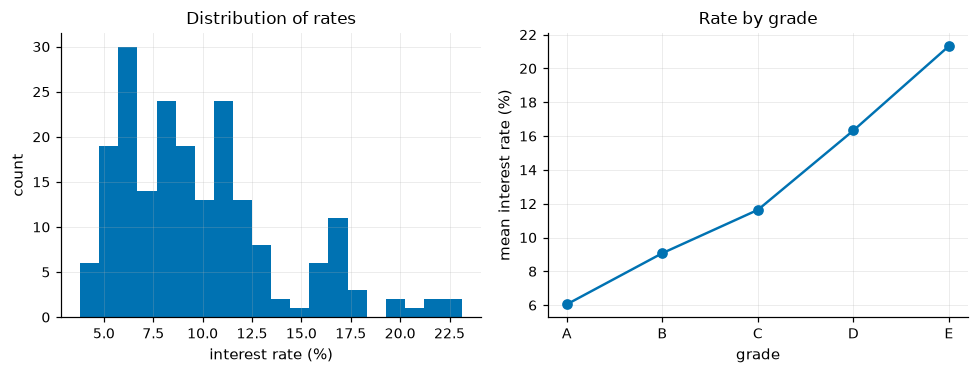

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

axes[0].hist(loans["int_rate"], bins=20)
axes[0].set_xlabel("interest rate (%)")
axes[0].set_ylabel("count")
axes[0].set_title("Distribution of rates")

order = list("ABCDE")
mean_by_grade = loans.groupby("grade")["int_rate"].mean().reindex(order)
axes[1].plot(order, mean_by_grade, marker="o")
axes[1].set_xlabel("grade")
axes[1].set_ylabel("mean interest rate (%)")
axes[1].set_title("Rate by grade")

plt.show()

*Figure 5.1 — the synthetic loan book: pooled interest-rate distribution (left) and the mean rate rising monotonically across grades by construction of the DGP (right).*

The pattern to memorise is exactly the one above: `fig, ax = plt.subplots(...)` creates the objects; every subsequent call names its target axes; labels and titles are set on the axes, not via global state. Grammar-of-graphics ports exist in Python (plotnine most directly), but the scientific ecosystem speaks matplotlib, and fluency in the object model is what lets you adjust any figure a library hands back to you. All figures in this course go through the small theme in `src/tunnel_mpl.py`, applied once per notebook in the header; every figure carries axis labels and a one-sentence caption in the following markdown cell.

## 6 · Simulation study: the cost of trusting row order

**Claim under test.** pandas index alignment makes label-keyed arithmetic invariant to row order, while positional (R-style) arithmetic is correct only when every table happens to share one ordering — and when orderings diverge, the resulting errors are large at row level and material at portfolio level.

The setting is a miniature credit portfolio. For $n$ obligors, expected loss is

$$\mathrm{EL}_i = \mathrm{PD}_i \cdot \mathrm{LGD}_i \cdot \mathrm{EAD}_i, \qquad \mathrm{EL} = \sum_{i=1}^{n} \mathrm{EL}_i, \tag{6.1}$$

with probability of default, loss given default, and exposure at default drawn from a known DGP. Risk parameters and exposures arrive from *different source systems*, each sorted its own way — the realistic case, and the one where habits formed on positional arithmetic fail.

In [28]:
n_obl = 500
obligor_ids = [f"OBL{i:04d}" for i in range(n_obl)]

risk = pd.DataFrame(
    {
        "pd_": rng.beta(2.0, 30.0, size=n_obl),        # PDs of a few per cent
        "lgd": rng.uniform(0.2, 0.8, size=n_obl),
    },
    index=pd.Index(obligor_ids, name="obligor"),
)
exposure = pd.Series(
    rng.lognormal(mean=10.0, sigma=1.0, size=n_obl),
    index=risk.index,
    name="ead",
)

el_true = float((risk["pd_"] * risk["lgd"] * exposure).sum())
print(f"true portfolio EL: {el_true:,.0f}")

true portfolio EL: 558,248


Now the experiment. In each of 1 000 replications, the exposure system delivers its table in a fresh, arbitrary row order. We compute portfolio EL two ways: **aligned**, multiplying the pandas objects and letting the index pair obligors; and **positional**, extracting NumPy arrays from each table as delivered and multiplying by row — the R reflex. We record the relative error of each against the known truth.

In [29]:
n_rep = 1_000
rel_err_aligned = np.empty(n_rep)
rel_err_positional = np.empty(n_rep)

for r in range(n_rep):
    ead_shuffled = exposure.sample(frac=1.0, random_state=rng)  # new arrival order
    el_aligned = float((risk["pd_"] * risk["lgd"] * ead_shuffled).sum())
    el_positional = float(
        (risk["pd_"].to_numpy() * risk["lgd"].to_numpy() * ead_shuffled.to_numpy()).sum()
    )
    rel_err_aligned[r] = (el_aligned - el_true) / el_true
    rel_err_positional[r] = (el_positional - el_true) / el_true

print(f"aligned    | max |rel. error|: {np.abs(rel_err_aligned).max():.2e}")
print(f"positional | mean |rel. error|: {np.abs(rel_err_positional).mean():.2%}"
      f", 95th percentile: {np.quantile(np.abs(rel_err_positional), 0.95):.2%}")

aligned    | max |rel. error|: 0.00e+00
positional | mean |rel. error|: 3.71%, 95th percentile: 9.23%


In [30]:
row_level_wrong = (
    risk["pd_"].to_numpy() * risk["lgd"].to_numpy() * ead_shuffled.to_numpy()
    != (risk["pd_"] * risk["lgd"] * ead_shuffled).to_numpy()
).mean()
print(f"share of obligor-level ELs wrong under positional arithmetic: {row_level_wrong:.1%}")

share of obligor-level ELs wrong under positional arithmetic: 99.8%


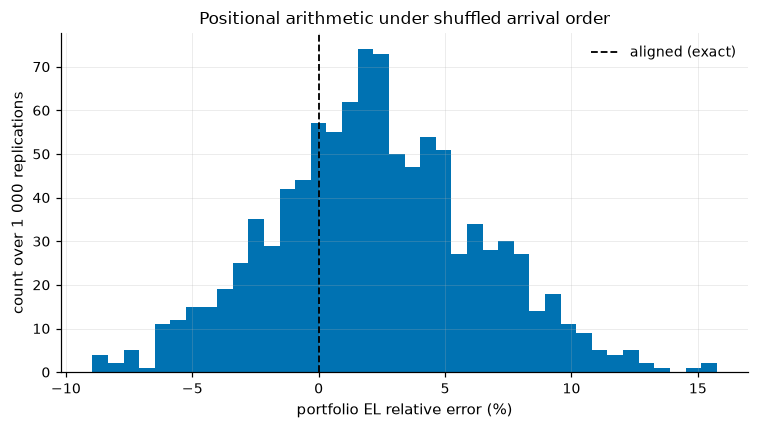

In [31]:
fig, ax = plt.subplots()
ax.hist(100 * rel_err_positional, bins=40)
ax.axvline(0.0, color="black", linewidth=1.2, linestyle="--", label="aligned (exact)")
ax.set_xlabel("portfolio EL relative error (%)")
ax.set_ylabel("count over 1 000 replications")
ax.set_title("Positional arithmetic under shuffled arrival order")
ax.legend()
plt.show()

*Figure 6.1 — distribution of the portfolio-EL relative error when arrays are multiplied positionally across differently-ordered tables; the dashed line marks the aligned computation, which is exact (error at floating-point precision) in every replication.*

**Verdict.** The evidence supports the claim. Aligned arithmetic reproduced the true EL to floating-point precision in all 1 000 replications, regardless of arrival order. Positional arithmetic mis-assigned essentially every obligor's exposure (≈100% of row-level ELs wrong) and produced portfolio-level errors typically of a few per cent — small enough to look plausible, which is precisely the danger: nothing about the output signals that the number is wrong. The general lesson carries beyond pandas: computations should be keyed on identifiers, and positional shortcuts admitted only across arrays extracted from a single, already-aligned object.

### Exercises — §6

**6.1 (A.)** Your exposure system can only emit plain NumPy arrays together with a separate array of obligor IDs. State the discipline that restores the safety demonstrated above before any positional arithmetic is performed, and give the one-line pandas idiom that implements it.

## 7 · Further reading

- McKinney, W. *Python for Data Analysis*, 3rd ed. (Wiley/O'Reilly; free online at wesmckinney.com/book). The reference for pandas mechanics — consult by chapter, do not read cover-to-cover.
- pandas user guide, "Copy-on-Write" — the authoritative statement of the semantics in §3.3.
- NumPy user guide, "Broadcasting" — the official statement of the rules in §2.4, with diagrams.
- Harris, C. R. et al. (2020). "Array programming with NumPy." *Nature* 585, 357–362. The design rationale for the array model in §2.